In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import torch.optim as optim
import os

In [34]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MNISTAutoencoder(nn.Module):
    def __init__(self):
        super(MNISTAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(True),
            nn.Linear(128, 64),
            nn.ReLU(True),
            nn.Linear(64, 12),
            nn.ReLU(True),
            nn.Linear(12, 20)  
        )
        self.decoder = nn.Sequential(
            nn.Linear(20, 12),
            nn.ReLU(True),
            nn.Linear(12, 64),
            nn.ReLU(True),
            nn.Linear(64, 128),
            nn.ReLU(True),
            nn.Linear(128, 28*28),
            nn.Sigmoid()  
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)  
        z = self.encoder(x)
        out = self.decoder(z)
        out = out.view(x.size(0), 1, 28, 28)  
        return out

    

In [35]:
transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])


transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=os.cpu_count())
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=os.cpu_count())


In [36]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MNISTAutoencoder().to(device)
loss_fn = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-4)

In [37]:
num_epochs = 30
for epoch in range(num_epochs):
    model.train()
    train_losses = 0
    for img, _ in train_loader:
        img = img.to(device)
        pred_img = model(img)
        loss = loss_fn(pred_img, img)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses += loss.item()
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {train_losses/len(train_loader):.4f}")


Epoch [1/30], Loss: 0.1358
Epoch [2/30], Loss: 0.0702
Epoch [3/30], Loss: 0.0681
Epoch [4/30], Loss: 0.0666
Epoch [5/30], Loss: 0.0655
Epoch [6/30], Loss: 0.0645
Epoch [7/30], Loss: 0.0632
Epoch [8/30], Loss: 0.0615
Epoch [9/30], Loss: 0.0598
Epoch [10/30], Loss: 0.0581
Epoch [11/30], Loss: 0.0567
Epoch [12/30], Loss: 0.0555
Epoch [13/30], Loss: 0.0541
Epoch [14/30], Loss: 0.0525
Epoch [15/30], Loss: 0.0510
Epoch [16/30], Loss: 0.0499
Epoch [17/30], Loss: 0.0490
Epoch [18/30], Loss: 0.0480
Epoch [19/30], Loss: 0.0469
Epoch [20/30], Loss: 0.0460
Epoch [21/30], Loss: 0.0451
Epoch [22/30], Loss: 0.0444
Epoch [23/30], Loss: 0.0438
Epoch [24/30], Loss: 0.0431
Epoch [25/30], Loss: 0.0425
Epoch [26/30], Loss: 0.0415
Epoch [27/30], Loss: 0.0403
Epoch [28/30], Loss: 0.0394
Epoch [29/30], Loss: 0.0386
Epoch [30/30], Loss: 0.0379


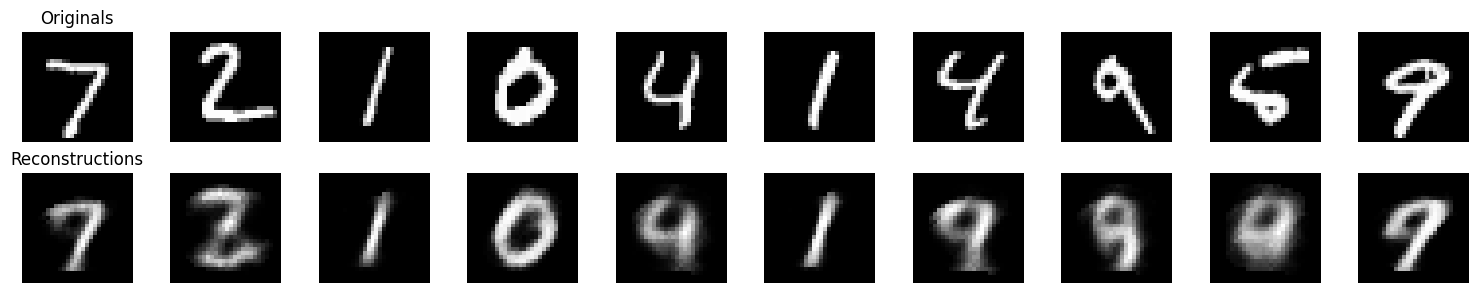

In [38]:
import matplotlib.pyplot as plt

def show_reconstructions(model, dataloader):
    model.eval()
    with torch.no_grad():
        for img, _ in dataloader:
            img = img.to(device)
            output = model(img)
            break  # just show one batch

    img = img.cpu().view(-1, 28, 28)
    output = output.cpu().view(-1, 28, 28)
    
    fig, axes = plt.subplots(2, 10, figsize=(15, 3))
    for i in range(10):
        axes[0][i].imshow(img[i], cmap='gray')
        axes[0][i].axis('off')
        axes[1][i].imshow(output[i], cmap='gray')
        axes[1][i].axis('off')
    axes[0][0].set_title('Originals')
    axes[1][0].set_title('Reconstructions')
    plt.tight_layout()
    plt.show()

show_reconstructions(model, test_loader)


In [46]:
latent_dim = 20 

def get_latent_stats(model, dataloader):
    latents = []
    with torch.no_grad():
        for x, _ in dataloader:
            x = x.to(device)
            z = model.encoder(x.view(x.size(0), -1))
            latents.append(z.cpu())
    latents = torch.cat(latents)
    return latents.mean(dim=0), latents.std(dim=0)

mean_z, std_z = get_latent_stats(model, train_loader)
print(f"Mean : {mean_z} | Standard_deviation : {std_z}")
noise_z = torch.randn(12, latent_dim) * std_z + mean_z
print("Noise : ", noise_z)


Mean : tensor([  8.1265,   4.8686,  -8.0094,   5.4799, -22.5490,  -6.8819,  15.5624,
        -19.1813, -32.2369,  -8.9848,  18.7750, -11.5494,  -5.7641,  32.4918,
         23.5371,  -3.6798,  29.8056,  -1.4548,  23.8119,  13.7910]) | Standard_deviation : tensor([ 4.1275,  5.1433,  9.6769,  5.6071, 10.8726,  3.6332,  8.0612,  9.0399,
        13.5244,  6.4183, 10.6465,  8.9027,  5.3926, 16.8766, 10.6430,  4.5087,
        13.4447,  2.6310, 11.1756, 10.2879])
Noise :  tensor([[  7.6104,  17.6356,  -4.7344,  -4.5910,  -6.3578,  -5.8687,  10.7384,
         -20.8515, -17.0621, -12.0381,   7.2574,   1.4445,  -5.6851,  48.2990,
          31.6316,  -7.9189,  38.1415,   1.5490,  20.4660,  12.0160],
        [ 14.2806,   7.9990,  -0.1866,   5.3680, -13.5637,  -4.6197,  12.8725,
         -31.2252, -36.3922, -13.8146,  28.5819,  -4.0960,  -3.5504,  42.7154,
           5.7960,  -2.9674,  44.9690,  -5.2871,  23.1675,  15.1096],
        [ 11.9586,  -5.0190, -12.7546,  -5.7004,  -4.9661, -13.1427,   6.43

In [52]:

mean = 5.0
std_dev = 1.0
num_samples = 12

noise = torch.randn(num_samples, latent_dim) * std_dev + mean  
print("Noise : ", noise)

Noise :  tensor([[4.2932, 5.8113, 4.3534, 6.3049, 6.1395, 4.9426, 5.7555, 4.8694, 2.8325,
         5.1330, 5.7214, 4.6288, 2.7722, 3.3401, 6.2921, 4.6295, 5.9120, 5.4670,
         4.4719, 4.8226],
        [3.8099, 5.9141, 4.3374, 5.9049, 4.4091, 6.9838, 5.3309, 4.2951, 5.9612,
         4.9724, 3.8243, 4.6457, 5.4076, 4.8953, 4.6074, 7.1225, 4.0974, 2.5043,
         5.9000, 3.6979],
        [5.7884, 3.7257, 5.6045, 4.8237, 4.8528, 4.2343, 5.3571, 3.4610, 5.6335,
         4.6120, 4.5394, 5.6272, 5.7033, 5.4355, 5.6913, 6.5131, 4.3998, 3.0679,
         3.9945, 4.1833],
        [3.7014, 5.5647, 5.2181, 3.5785, 4.6975, 4.9579, 3.7771, 6.4565, 3.7529,
         4.2167, 4.8850, 5.1139, 4.5777, 3.2441, 4.6918, 5.3561, 3.1790, 7.0929,
         5.1236, 4.3691],
        [7.7893, 4.3110, 3.6268, 5.8768, 5.6704, 4.4327, 4.1961, 3.1579, 5.6333,
         5.5975, 4.9410, 3.9066, 4.4423, 4.4556, 6.0372, 5.4789, 4.3377, 4.5408,
         6.3041, 4.4712],
        [4.6136, 6.2929, 5.7596, 4.7843, 3.5543, 5.

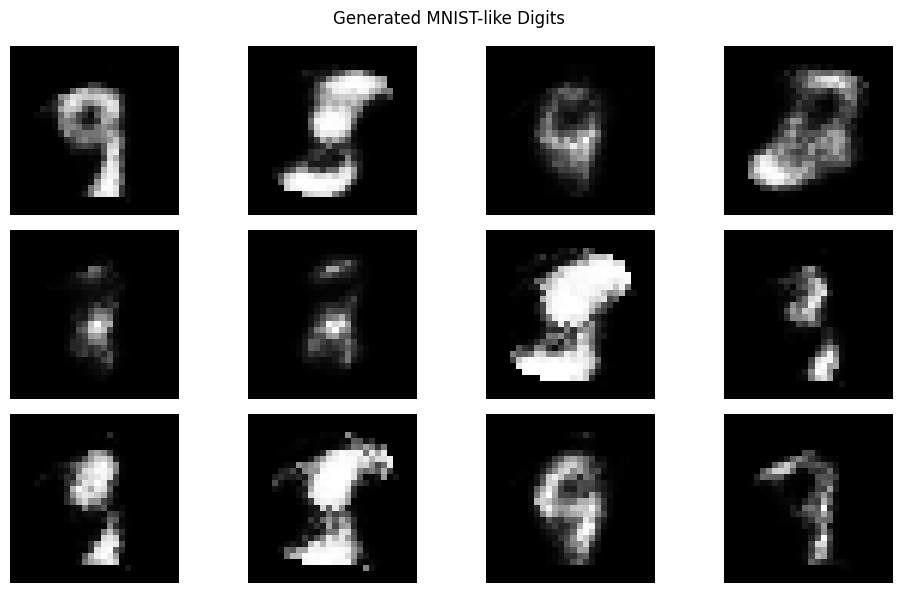

In [54]:
import torch
import matplotlib.pyplot as plt

model.eval()

mean_z, std_z = get_latent_stats(model, train_loader)
noise_z = torch.randn(12, latent_dim) * std_z + mean_z

# noise = torch.randn(num_samples, latent_dim) * std_dev + mean  
# noise = noise.to(device)
noise = noise_z.to(device)

with torch.no_grad():
    generated = model.decoder(noise)  
    generated = generated.view(-1, 28, 28).cpu()

plt.figure(figsize=(10, 6))
for i in range(num_samples):
    plt.subplot(3, num_samples//3, i + 1)
    plt.imshow(generated[i], cmap='gray')
    plt.axis('off')
plt.suptitle("Generated MNIST-like Digits ")
plt.tight_layout()
plt.show()
